In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [5]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "assets" / "data"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
file_path = RAW_DATA_DIR / "photovoltaic_spiring_2022_2023.csv"

spring = pd.read_csv(file_path)

In [7]:
spring["datetime"] = pd.to_datetime(
    spring["timestamp"],
    unit="D",
    origin="1899-12-30"
).dt.round("min")

In [8]:
spring["date"] = spring["datetime"].dt.date
spring["hour"] = spring["datetime"].dt.hour
spring["hour_decimal"] = (
    spring["datetime"].dt.hour
    + spring["datetime"].dt.minute / 60
)

In [9]:
hourly_power = (
    spring.groupby("hour")["Active_Power"]
    .agg(["mean", "median", "min", "max"])
)

display(hourly_power)

,mean,median,min,max
hour,,,,
0,4.487308,-0.364442,-0.451048,378.078516
1,4.483088,-0.365193,-0.449480,378.078102
2,4.493807,-0.365350,-0.398218,378.078269
3,4.483145,-0.366009,-0.400398,378.078516
4,4.481967,-0.367195,-0.399861,378.078712
5,4.552120,-0.368386,-0.403444,378.185859
6,29.302124,13.482154,-0.375640,396.456457
7,189.613304,167.979878,7.108677,632.782480
8,489.900124,508.243390,39.932969,916.533693


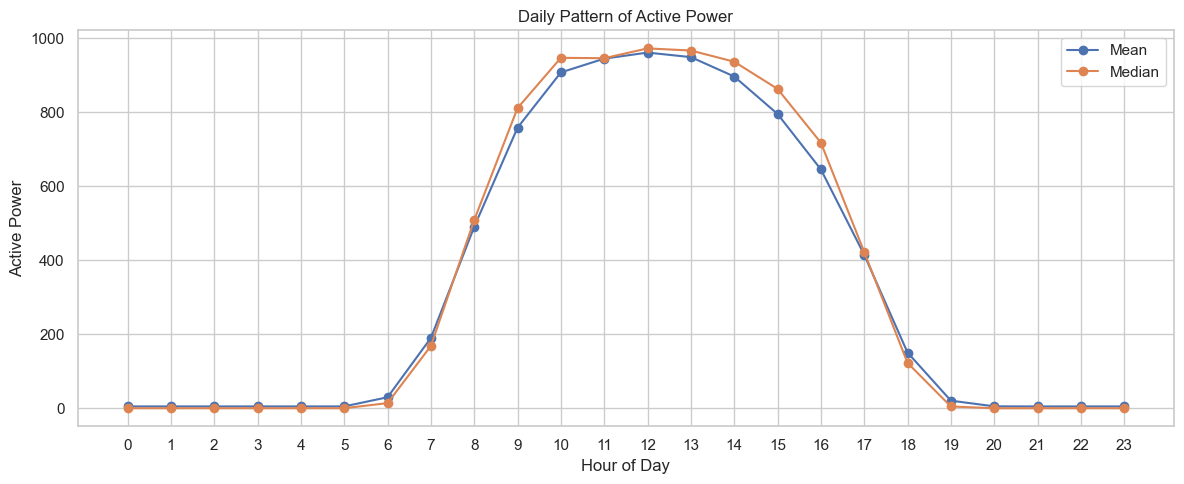

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_power.index,
    hourly_power["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    hourly_power.index,
    hourly_power["median"],
    marker="o",
    label="Median"
)

plt.title("Daily Pattern of Active Power")
plt.xlabel("Hour of Day")
plt.ylabel("Active Power")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

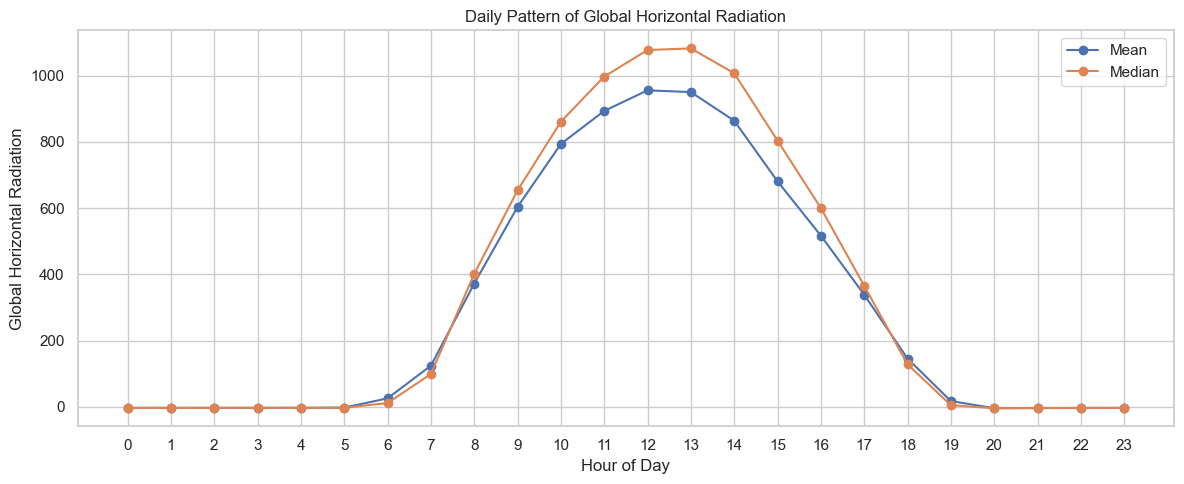

In [11]:
hourly_radiation = (
    spring.groupby("hour")["Global_Horizontal_Radiation"]
    .agg(["mean", "median", "min", "max"])
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_radiation.index,
    hourly_radiation["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    hourly_radiation.index,
    hourly_radiation["median"],
    marker="o",
    label="Median"
)

plt.title("Daily Pattern of Global Horizontal Radiation")
plt.xlabel("Hour of Day")
plt.ylabel("Global Horizontal Radiation")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
negative_power = spring[
    spring["Active_Power"] < 0
].copy()

print(
    f"Negative Active_Power observations: "
    f"{len(negative_power):,}"
)

print(
    f"Percentage: "
    f"{len(negative_power) / len(spring) * 100:.2f}%"
)

display(
    negative_power[
        ["Active_Power", "Global_Horizontal_Radiation"]
    ].describe()
)

Negative Active_Power observations: 9,947
Percentage: 44.28%


,Active_Power,Global_Horizontal_Radiation
count,9947.000000,9598.000000
mean,-0.377331,-3.122933
std,0.040911,1.682659
min,-0.478085,-10.360827
25%,-0.388763,-4.086185
50%,-0.368388,-3.264060
75%,-0.360168,-2.279225
max,-0.024015,44.225288


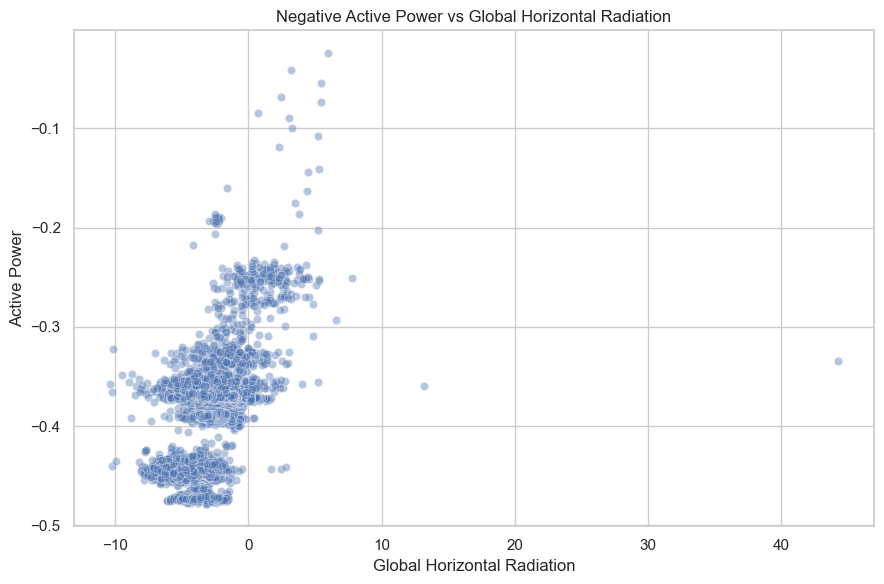

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=negative_power,
    x="Global_Horizontal_Radiation",
    y="Active_Power",
    alpha=0.4
)

plt.title("Negative Active Power vs Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Active Power")

plt.tight_layout()
plt.show()

hour
0     923
1     924
2     922
3     924
4     924
5     913
6     329
18      1
19    396
20    919
21    924
22    924
23    924
dtype: int64

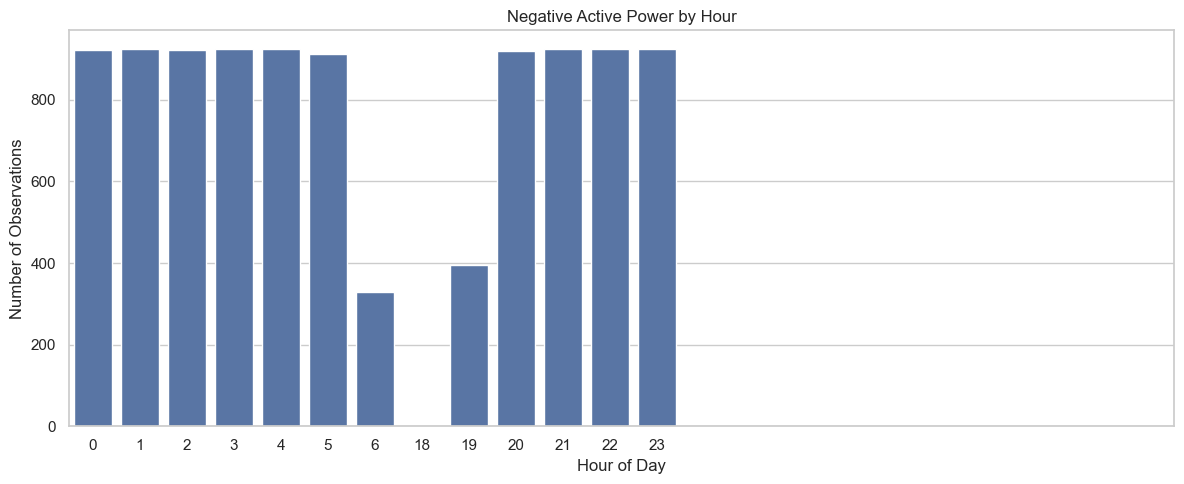

In [14]:
# Negative Active Power in Times
negative_power_by_hour = (
    negative_power
    .groupby("hour")
    .size()
)

display(negative_power_by_hour)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=negative_power_by_hour.index,
    y=negative_power_by_hour.values
)

plt.title("Negative Active Power by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [15]:
# Analisis GHI Negative
negative_radiation = spring[
    spring["Global_Horizontal_Radiation"] < 0
].copy()

print(
    f"Negative GHI observations: "
    f"{len(negative_radiation):,}"
)

print(
    f"Percentage: "
    f"{len(negative_radiation) / spring["Global_Horizontal_Radiation"].notna().sum() * 100:.2f}%"
)

display(
    negative_radiation[
        ["Global_Horizontal_Radiation", "Active_Power"]
    ].describe()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    negative_radiation["Global_Horizontal_Radiation"],
    bins=40
)

plt.title("Distribution of Negative Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

SyntaxError: f-string: unmatched '[' (1860400186.py, line 13)

hour
0     923
1     924
2     922
3     924
4     924
5     913
6     329
18      1
19    396
20    919
21    924
22    924
23    924
dtype: int64

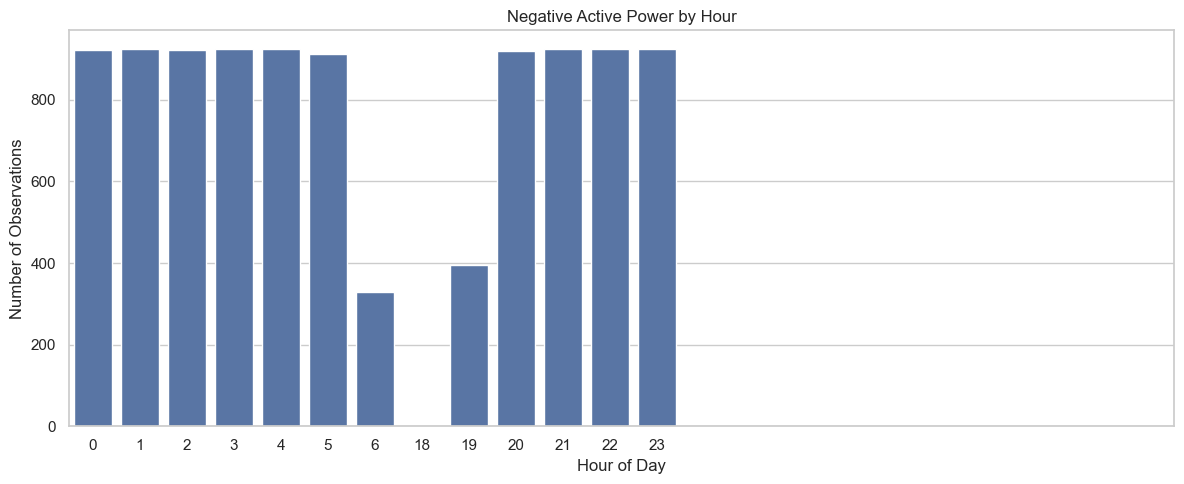

In [ ]:
# Negative Active Power
negative_power_by_hour = (
    negative_power
    .groupby("hour")
    .size()
)

display(negative_power_by_hour)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=negative_power_by_hour.index,
    y=negative_power_by_hour.values
)

plt.title("Negative Active Power by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

Negative GHI observations: 9,307
Percentage: 43.13%


,Global_Horizontal_Radiation,Active_Power
count,9307.000000,9304.000000
mean,-3.281477,-0.302017
std,1.357119,2.699575
min,-10.360827,-0.478085
25%,-4.113136,-0.389414
50%,-3.309473,-0.368661
75%,-2.387055,-0.360669
max,-0.001411,171.906024


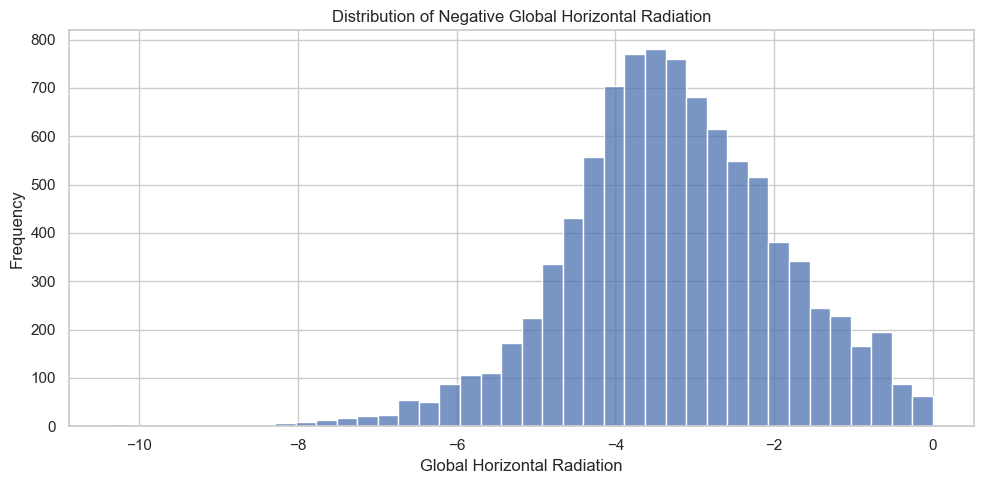

In [ ]:
# Negative GHI Analysis

negative_radiation = spring[
    spring["Global_Horizontal_Radiation"] < 0
].copy()

negative_radiation_count = len(negative_radiation)
valid_radiation_count = spring["Global_Horizontal_Radiation"].notna().sum()

print(f"Negative GHI observations: {negative_radiation_count:,}")
print(
    f"Percentage: "
    f"{negative_radiation_count / valid_radiation_count * 100:.2f}%"
)

display(
    negative_radiation[
        ["Global_Horizontal_Radiation", "Active_Power"]
    ].describe()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    negative_radiation["Global_Horizontal_Radiation"],
    bins=40
)

plt.title("Distribution of Negative Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

hour
0     881
1     884
2     892
3     882
4     893
5     835
6     210
19    317
20    881
21    875
22    889
23    868
dtype: int64

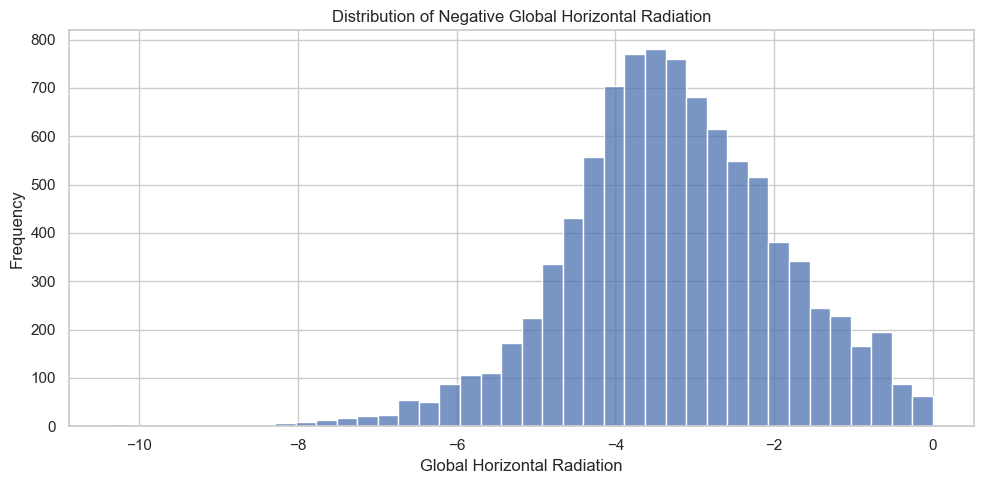

In [ ]:
# GHI Negative vs Times
negative_radiation_by_hour = (
    negative_radiation
    .groupby("hour")
    .size()
)

display(negative_radiation_by_hour)

plt.figure(figsize=(10, 5))

sns.histplot(
    negative_radiation["Global_Horizontal_Radiation"],
    bins=40
)

plt.title("Distribution of Negative Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
eda_data = spring.copy()

eda_data = eda_data.replace(
    -299999968,
    np.nan
)

eda_data["GHI_Group"] = pd.qcut(
    eda_data["Global_Horizontal_Radiation"],
    q=10,
    duplicates="drop"
)

ghi_power_summary = (
    eda_data
    .groupby("GHI_Group", observed=True)["Active_Power"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(ghi_power_summary)

,count,mean,median,min,max
GHI_Group,,,,,
"(-10.362, -4.172]",2157,-0.397472,-0.369492,-0.477476,-0.320160
"(-4.172, -3.426]",2158,-0.374220,-0.364706,-0.477289,-0.217933
"(-3.426, -2.632]",2157,-0.317461,-0.369841,-0.478085,67.977963
"(-2.632, -1.215]",2157,-0.156122,-0.369525,-0.477058,171.906024
"(-1.215, 51.711]",2158,24.226490,4.569297,-0.454150,387.972030
"(51.711, 215.466]",2158,167.179953,144.669464,5.189026,769.415604
"(215.466, 476.962]",2158,462.832877,455.147820,45.957331,992.477604
"(476.962, 753.967]",2158,768.213171,775.687542,53.383628,1131.162643
"(753.967, 1013.448]",2158,978.820858,995.300819,384.414852,1329.730328


Valid observations: 21579
Unique valid values: [0.]
Variance: 0.0


count    21579.000000
mean         0.000140
std          0.002169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.141667
Name: Weather_Daily_Rainfall, dtype: float64

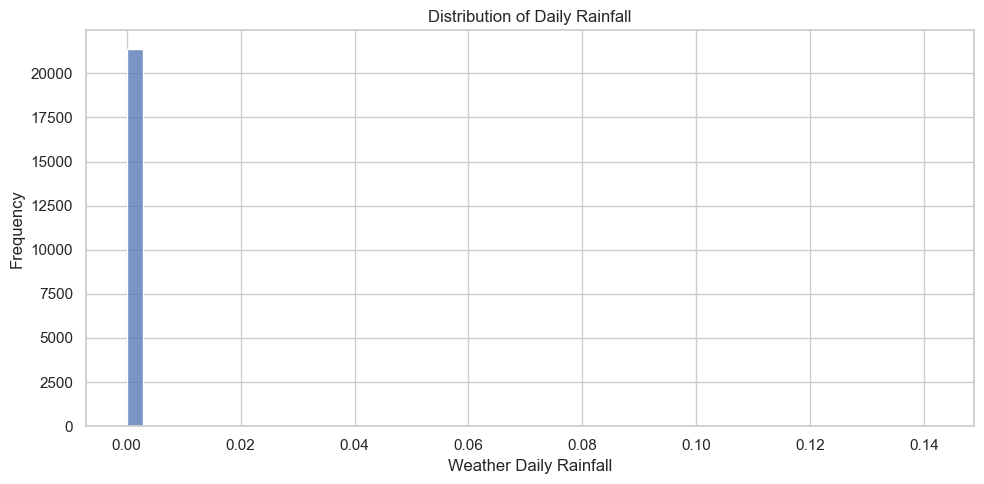

Zero rainfall percentage: 97.26122619213123


In [ ]:
hail_eda = spring["Hail_Accumulation"].replace(
    -299999968,
    np.nan
)

print("Valid observations:", hail_eda.notna().sum())
print("Unique valid values:", hail_eda.dropna().unique())
print("Variance:", hail_eda.var())

rainfall_eda = spring["Weather_Daily_Rainfall"].replace(
    -299999968,
    np.nan
)

display(rainfall_eda.describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    rainfall_eda.dropna(),
    bins=50
)

plt.title("Distribution of Daily Rainfall")
plt.xlabel("Weather Daily Rainfall")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    "Zero rainfall percentage:",
    (
        (rainfall_eda == 0).sum()
        / rainfall_eda.notna().sum()
        * 100
    )
)

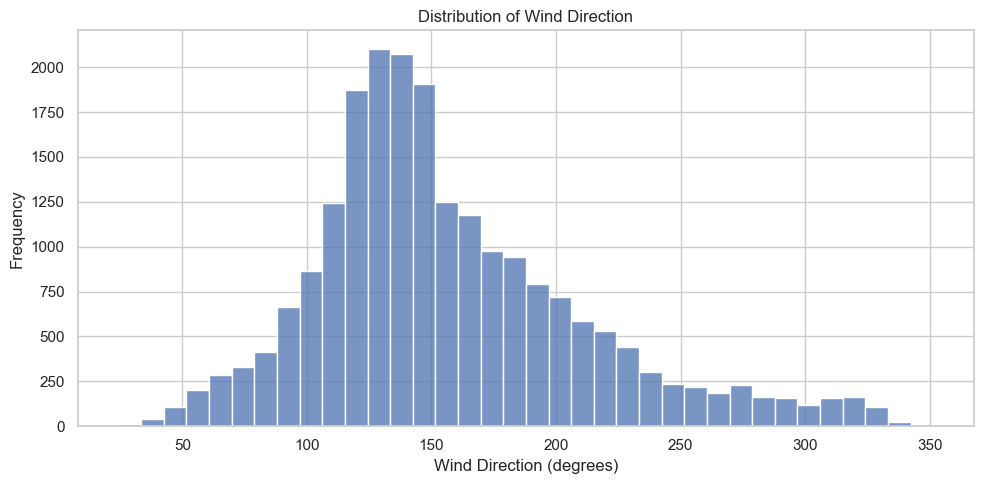

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_data,
    x="Wind_Direction",
    bins=36
)

plt.title("Distribution of Wind Direction")
plt.xlabel("Wind Direction (degrees)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Outlier Analysis
outlier_summary = []

weather_columns = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "Hail_Accumulation"
]

weather_missing = spring[weather_columns].isna().all(axis=1)

print(
    f"Rows with all weather variables missing: "
    f"{weather_missing.sum():,}"
)
outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

Rows with all weather variables missing: 884


""


In [ ]:
# Missing Weather
# Weather feature columns

weather_columns = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "Hail_Accumulation"
]

group_id = weather_missing.ne(
    weather_missing.shift()
).cumsum()

missing_blocks = (
    spring.loc[weather_missing]
    .groupby(group_id[weather_missing])
    .agg(
        start=("datetime", "min"),
        end=("datetime", "max"),
        rows=("datetime", "size")
    )
)

missing_blocks["duration_minutes"] = (
    missing_blocks["end"]
    - missing_blocks["start"]
).dt.total_seconds() / 60 + 5

missing_blocks = missing_blocks.sort_values(
    "rows",
    ascending=False
)

display(missing_blocks.head(20))

,start,end,rows,duration_minutes
56,2022-12-18 16:50:00,2022-12-19 09:35:00,202,1010.0
44,2022-12-09 06:55:00,2022-12-09 10:00:00,38,190.0
58,2022-12-22 02:10:00,2022-12-22 04:25:00,28,140.0
184,2023-02-03 14:30:00,2023-02-03 16:15:00,22,110.0
186,2023-02-03 20:20:00,2023-02-03 22:00:00,21,105.0
78,2022-12-29 22:30:00,2022-12-29 23:55:00,18,90.0
206,2023-02-05 14:50:00,2023-02-05 16:15:00,18,90.0
306,2023-02-11 07:05:00,2023-02-11 08:25:00,17,85.0
210,2023-02-05 17:50:00,2023-02-05 18:55:00,14,70.0
126,2023-01-25 06:40:00,2023-01-25 07:45:00,14,70.0


In [16]:
# EDA Summary

weather_columns = [
    "Wind_Speed",
    "Weather_Temperature_Celsius",
    "Global_Horizontal_Radiation",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Max_Wind_Speed",
    "Air_Pressure",
    "Hail_Accumulation"
]

ghi_correlation = spring[
    ["Active_Power", "Global_Horizontal_Radiation"]
].corr().loc[
    "Active_Power",
    "Global_Horizontal_Radiation"
]

hail_valid = spring["Hail_Accumulation"].replace(
    -299999968,
    np.nan
)

eda_summary = pd.DataFrame({
    "Aspect": [
        "Dataset size",
        "Duplicate rows",
        "Timestamp",
        "Sampling interval",
        "Missing Active_Power",
        "Missing weather observations",
        "Rainfall sentinel value",
        "Hail sentinel value",
        "Hail valid variation",
        "Active_Power range",
        "GHI range",
        "GHI-Active_Power correlation"
    ],
    "Finding": [
        f"{len(spring):,} rows × {spring.shape[1]} columns",
        f"{spring.duplicated().sum():,}",
        (
            f"{spring['datetime'].min()} "
            f"to {spring['datetime'].max()}"
        ),
        "Approximately 5 minutes",
        f"{spring['Active_Power'].isna().sum():,}",
        f"{spring[weather_columns].isna().any(axis=1).sum():,}",
        "-299999968",
        "-299999968",
        (
            "No valid variation"
            if hail_valid.nunique(dropna=True) <= 1
            else "Has variation"
        ),
        (
            f"{spring['Active_Power'].min():.4f} "
            f"to {spring['Active_Power'].max():.4f}"
        ),
        (
            f"{spring['Global_Horizontal_Radiation'].min():.4f} "
            f"to {spring['Global_Horizontal_Radiation'].max():.4f}"
        ),
        f"{ghi_correlation:.4f}"
    ]
})

display(eda_summary)

,Aspect,Finding
0,Dataset size,"22,464 rows × 14 columns"
1,Duplicate rows,0
2,Timestamp,2022-12-01 00:00:00 to 2023-02-28 23:55:00
3,Sampling interval,Approximately 5 minutes
4,Missing Active_Power,3
5,Missing weather observations,884
6,Rainfall sentinel value,-299999968
7,Hail sentinel value,-299999968
8,Hail valid variation,No valid variation
9,Active_Power range,-0.4781 to 1431.9404
